In [1]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix
from sklearn.preprocessing import LabelEncoder
import seaborn as sns

import cv2
from pathlib import Path
import pickle

import warnings
warnings.filterwarnings('ignore')

In [2]:
# Deep Learning Libraries
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers, models
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau
    

## Dataset Handler for Signal Images 

In [3]:
class SignalImageDataset:
    
    def __init__(self, dataset_path):
        self.dataset_path = Path(dataset_path)
        self.image_paths = []
        self.labels = []
        self.label_encoder = LabelEncoder()
        self.load_dataset()
    
    def load_dataset(self):
        """Load all images and their corresponding labels"""
        print("Loading dataset...")
        
        for machine_folder in self.dataset_path.iterdir():
            if machine_folder.is_dir():
                machine_name = machine_folder.name
                print(f"Loading images from {machine_name}...")
                
                for image_path in machine_folder.glob("*.png"):
                    self.image_paths.append(str(image_path))
                    self.labels.append(machine_name)
        
        # Encode labels
        self.labels_encoded = self.label_encoder.fit_transform(self.labels)
        
        print(f"Dataset loaded: {len(self.image_paths)} images")
        print(f"Classes: {list(self.label_encoder.classes_)}")
        print(f"Class distribution:")
        unique, counts = np.unique(self.labels, return_counts=True)
        for cls, count in zip(unique, counts):
            print(f"  {cls}: {count} images")
    
    def load_and_preprocess_image(self, image_path, target_size=(150, 400)):
        """Load and preprocess a single image"""
        try:
            # Load image
            img = cv2.imread(image_path)
            if img is None:
                return None
            
            # Convert BGR to RGB
            img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
            
            # Resize to target size
            img = cv2.resize(img, target_size)
            
            # Normalize pixel values
            img = img.astype(np.float32) / 255.0
            
            return img
        except Exception as e:
            print(f"Error loading image {image_path}: {e}")
            return None
    
    def get_data_arrays(self, target_size=(150, 400)):
        """Convert dataset to numpy arrays for training"""
        print("Converting images to arrays...")
        
        X = []
        y = []
        
        for i, (img_path, label) in enumerate(zip(self.image_paths, self.labels_encoded)):
            if i % 100 == 0:
                print(f"Processed {i}/{len(self.image_paths)} images")
            
            img = self.load_and_preprocess_image(img_path, target_size)
            if img is not None:
                X.append(img)
                y.append(label)
        
        return np.array(X), np.array(y)


## CNN model for signal classification 

In [4]:
class SignalCNNClassifier:
    
    def __init__(self, num_classes, input_shape=(150, 400, 3)):
        self.num_classes = num_classes
        self.input_shape = input_shape
        self.model = None
        self.history = None
        self.build_model()
    
    def build_model(self):
        """Build CNN architecture optimized for signal images"""
        
        self.model = models.Sequential([
            # First Convolutional Block
            layers.Conv2D(32, (3, 3), activation='relu', input_shape=self.input_shape),
            layers.BatchNormalization(),
            layers.MaxPooling2D((2, 2)),
            layers.Dropout(0.25),
            
            # Second Convolutional Block
            layers.Conv2D(64, (3, 3), activation='relu'),
            layers.BatchNormalization(),
            layers.MaxPooling2D((2, 2)),
            layers.Dropout(0.25),
            
            # Third Convolutional Block
            layers.Conv2D(128, (3, 3), activation='relu'),
            layers.BatchNormalization(),
            layers.MaxPooling2D((2, 2)),
            layers.Dropout(0.25),
            
            # Fourth Convolutional Block (for detailed feature extraction)
            layers.Conv2D(256, (3, 3), activation='relu'),
            layers.BatchNormalization(),
            layers.MaxPooling2D((2, 2)),
            layers.Dropout(0.3),
            
            # Global Average Pooling (better than Flatten for overfitting)
            layers.GlobalAveragePooling2D(),
            
            # Dense layers
            layers.Dense(512, activation='relu'),
            layers.BatchNormalization(),
            layers.Dropout(0.5),
            
            layers.Dense(256, activation='relu'),
            layers.BatchNormalization(),
            layers.Dropout(0.5),
            
            # Output layer
            layers.Dense(self.num_classes, activation='softmax')
        ])
        
        # Compile model
        self.model.compile(
            optimizer='adam',
            loss='sparse_categorical_crossentropy',
            metrics=['accuracy']
        )
        
        print("Model built successfully!")
        print(self.model.summary())
    
    def train(self, X_train, y_train, X_val, y_val, epochs=50, batch_size=32):
        """Train the CNN model"""
        
        # Data augmentation for better generalization
        datagen = ImageDataGenerator(
            rotation_range=5,
            width_shift_range=0.1,
            height_shift_range=0.1,
            horizontal_flip=False,  # Don't flip signals
            zoom_range=0.1,
            fill_mode='nearest'
        )
        
        # Callbacks
        callbacks = [
            EarlyStopping(
                monitor='val_accuracy',
                patience=10,
                restore_best_weights=True,
                verbose=1
            ),
            ReduceLROnPlateau(
                monitor='val_loss',
                factor=0.5,
                patience=5,
                min_lr=1e-7,
                verbose=1
            )
        ]
        
        print("Starting training...")
        
        # Train model
        self.history = self.model.fit(
            datagen.flow(X_train, y_train, batch_size=batch_size),
            steps_per_epoch=len(X_train) // batch_size,
            epochs=epochs,
            validation_data=(X_val, y_val),
            callbacks=callbacks,
            verbose=1
        )
        
        print("Training completed!")
        return self.history
    
    def evaluate(self, X_test, y_test, label_encoder):
        """Evaluate model performance"""
        
        # Predictions
        y_pred_proba = self.model.predict(X_test)
        y_pred = np.argmax(y_pred_proba, axis=1)
        
        # Accuracy
        accuracy = np.mean(y_pred == y_test)
        print(f"Test Accuracy: {accuracy:.4f}")
        
        # Classification report
        class_names = label_encoder.classes_
        report = classification_report(y_test, y_pred, target_names=class_names)
        print("\nClassification Report:")
        print(report)
        
        # Confusion Matrix
        cm = confusion_matrix(y_test, y_pred)
        
        plt.figure(figsize=(10, 8))
        sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
                   xticklabels=class_names, yticklabels=class_names)
        plt.title('Confusion Matrix')
        plt.ylabel('True Label')
        plt.xlabel('Predicted Label')
        plt.xticks(rotation=45)
        plt.yticks(rotation=45)
        plt.tight_layout()
        plt.savefig('confusion_matrix.png', dpi=300, bbox_inches='tight')
        plt.show()
        
        return accuracy, y_pred, y_pred_proba
    
    def plot_training_history(self):
        """Plot training history"""
        if self.history is None:
            print("No training history available")
            return
        
        fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 5))
        
        # Accuracy
        ax1.plot(self.history.history['accuracy'], label='Training Accuracy')
        ax1.plot(self.history.history['val_accuracy'], label='Validation Accuracy')
        ax1.set_title('Model Accuracy')
        ax1.set_xlabel('Epoch')
        ax1.set_ylabel('Accuracy')
        ax1.legend()
        ax1.grid(True)
        
        # Loss
        ax2.plot(self.history.history['loss'], label='Training Loss')
        ax2.plot(self.history.history['val_loss'], label='Validation Loss')
        ax2.set_title('Model Loss')
        ax2.set_xlabel('Epoch')
        ax2.set_ylabel('Loss')
        ax2.legend()
        ax2.grid(True)
        
        plt.tight_layout()
        plt.savefig('training_history.png', dpi=300, bbox_inches='tight')
        plt.show()
    
    def save_model(self, filepath):
        """Save the trained model"""
        self.model.save(filepath)
        print(f"Model saved to {filepath}")
    
    def load_model(self, filepath):
        """Load a pre-trained model"""
        self.model = keras.models.load_model(filepath)
        print(f"Model loaded from {filepath}")


## Advanced signal analysis and prediction system 

In [5]:
class SignalAnalyzer:
    """Advanced signal analysis and prediction system"""
    
    def __init__(self, model, label_encoder, dataset):
        self.model = model
        self.label_encoder = label_encoder
        self.dataset = dataset
    
    def predict_single_image(self, image_path, confidence_threshold=0.5):
        """Predict class for a single signal image"""
        
        # Load and preprocess image
        img = self.dataset.load_and_preprocess_image(image_path)
        if img is None:
            return None, None, None
        
        # Add batch dimension
        img_batch = np.expand_dims(img, axis=0)
        
        # Predict
        predictions = self.model.predict(img_batch, verbose=0)
        predicted_class_idx = np.argmax(predictions[0])
        confidence = predictions[0][predicted_class_idx]
        predicted_class = self.label_encoder.inverse_transform([predicted_class_idx])[0]
        
        # Get all class probabilities
        class_probabilities = {}
        for i, class_name in enumerate(self.label_encoder.classes_):
            class_probabilities[class_name] = predictions[0][i]
        
        return predicted_class, confidence, class_probabilities
    
    def analyze_signal_patterns(self, X_test, y_test, num_samples=5):
        """Analyze and visualize signal patterns for each class"""
        
        plt.figure(figsize=(20, 4 * len(self.label_encoder.classes_)))
        
        for class_idx, class_name in enumerate(self.label_encoder.classes_):
            # Get samples from this class
            class_indices = np.where(y_test == class_idx)[0]
            if len(class_indices) == 0:
                continue
            
            sample_indices = np.random.choice(class_indices, 
                                            min(num_samples, len(class_indices)), 
                                            replace=False)
            
            for i, idx in enumerate(sample_indices):
                plt.subplot(len(self.label_encoder.classes_), num_samples, 
                           class_idx * num_samples + i + 1)
                plt.imshow(X_test[idx])
                plt.title(f'{class_name}\nSample {i+1}')
                plt.axis('off')
        
        plt.tight_layout()
        plt.savefig('signal_patterns_analysis.png', dpi=300, bbox_inches='tight')
        plt.show()
    
    def extract_features(self, X, layer_name='global_average_pooling2d'):
        """Extract features from intermediate layer"""
        
        # Create feature extraction model
        feature_model = keras.Model(
            inputs=self.model.input,
            outputs=self.model.get_layer(layer_name).output
        )
        
        # Extract features
        features = feature_model.predict(X, verbose=0)
        return features
    
    def visualize_feature_space(self, X_test, y_test):
        """Visualize feature space using t-SNE"""
        try:
            from sklearn.manifold import TSNE
            from sklearn.decomposition import PCA
            
            # Extract features
            features = self.extract_features(X_test)
            
            # Reduce dimensions first with PCA, then t-SNE
            if features.shape[1] > 50:
                pca = PCA(n_components=50)
                features_pca = pca.fit_transform(features)
            else:
                features_pca = features
            
            # Apply t-SNE
            tsne = TSNE(n_components=2, random_state=42, perplexity=30)
            features_2d = tsne.fit_transform(features_pca)
            
            # Plot
            plt.figure(figsize=(12, 8))
            colors = plt.cm.Set3(np.linspace(0, 1, len(self.label_encoder.classes_)))
            
            for class_idx, (class_name, color) in enumerate(zip(self.label_encoder.classes_, colors)):
                mask = y_test == class_idx
                plt.scatter(features_2d[mask, 0], features_2d[mask, 1], 
                           c=[color], label=class_name, alpha=0.7, s=20)
            
            plt.title('Feature Space Visualization (t-SNE)')
            plt.xlabel('t-SNE Component 1')
            plt.ylabel('t-SNE Component 2')
            plt.legend()
            plt.grid(True, alpha=0.3)
            plt.tight_layout()
            plt.savefig('feature_space_visualization.png', dpi=300, bbox_inches='tight')
            plt.show()
            
        except ImportError:
            print("scikit-learn required for feature visualization. Install with: pip install scikit-learn")


## Main execution 

Starting Signal Computer Vision Classification Pipeline

 Step 1: Loading Dataset
Loading dataset...
Loading images from PT41...
Loading images from PT77...
Loading images from PT76...
Loading images from PT71...
Loading images from PT103...
Loading images from PT54...
Loading images from PT74...
Loading images from PT154...
Loading images from PT57...
Dataset loaded: 900 images
Classes: ['PT103', 'PT154', 'PT41', 'PT54', 'PT57', 'PT71', 'PT74', 'PT76', 'PT77']
Class distribution:
  PT103: 100 images
  PT154: 100 images
  PT41: 100 images
  PT54: 100 images
  PT57: 100 images
  PT71: 100 images
  PT74: 100 images
  PT76: 100 images
  PT77: 100 images

 Step 2: Preparing Data Arrays
Converting images to arrays...
Processed 0/900 images
Processed 100/900 images
Processed 200/900 images
Processed 300/900 images
Processed 400/900 images
Processed 500/900 images
Processed 600/900 images
Processed 700/900 images
Processed 800/900 images
Dataset shape: X=(900, 400, 150, 3), y=(900,)

 Step 3:

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 148, 398, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 148, 398, 32)   │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 74, 199, 32)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 74, 199, 32)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 72, 197, 64)    │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 72, 197, 64)    │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 36, 98, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 36, 98, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 34, 96, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 34, 96, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 17, 48, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 17, 48, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 15, 46, 256)    │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ (None, 15, 46, 256)    │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 7, 23, 256)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 7, 23, 256)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 256)            │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 512)            │       131,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_4           │ (None, 512)            │         2,048 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_4 (Dropout)             │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 256)            │       131,328 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_5           │ (None, 256)            │         1,02

 Total params: 658,633 (2.51 MB)

 Trainable params: 656,137 (2.50 MB)

 Non-trainable params: 2,496 (9.75 KB)

None
Starting training...
Epoch 1/30
19/19 ━━━━━━━━━━━━━━━━━━━━ 33s 2s/step - accuracy: 0.1386 - loss: 3.2924 - val_accuracy: 0.1111 - val_loss: 2.2092 - learning_rate: 0.0010
Epoch 2/30
19/19 ━━━━━━━━━━━━━━━━━━━━ 3s 54ms/step - accuracy: 0.1875 - loss: 3.0783 - val_accuracy: 0.1111 - val_loss: 2.2124 - learning_rate: 0.0010
Epoch 3/30
19/19 ━━━━━━━━━━━━━━━━━━━━ 30s 2s/step - accuracy: 0.2031 - loss: 2.7124 - val_accuracy: 0.1185 - val_loss: 2.2666 - learning_rate: 0.0010
Epoch 4/30
19/19 ━━━━━━━━━━━━━━━━━━━━ 3s 57ms/step - accuracy: 0.1562 - loss: 2.7459 - val_accuracy: 0.1111 - val_loss: 2.2702 - learning_rate: 0.0010
Epoch 5/30
19/19 ━━━━━━━━━━━━━━━━━━━━ 31s 2s/step - accuracy: 0.2297 - loss: 2.5392 - val_accuracy: 0.1111 - val_loss: 2.4190 - learning_rate: 0.0010
Epoch 6/30
 1/19 ━━━━━━━━━━━━━━━━━━━━ 28s 2s/step - accuracy: 0.1562 - loss: 2.7722
Epoch 6: ReduceLROnPlateau reducing learning rate to 0.0005000000237487257.
19/19 ━━━━━━━━━━━━━━━━━━━━ 3s 63ms/step - accuracy: 0.1562 - l

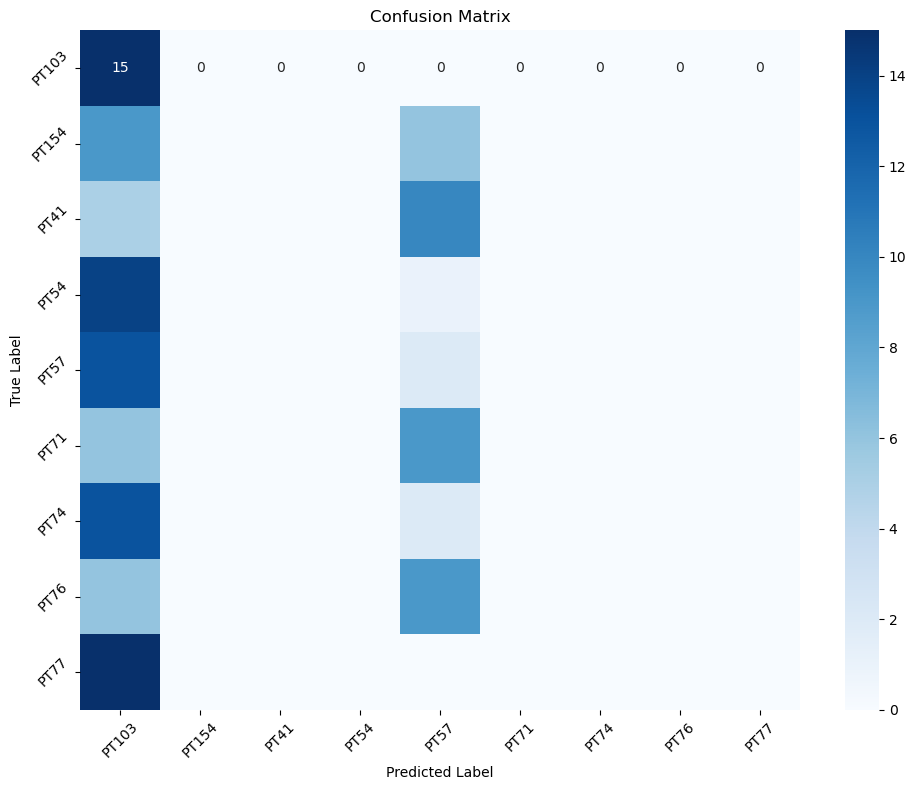

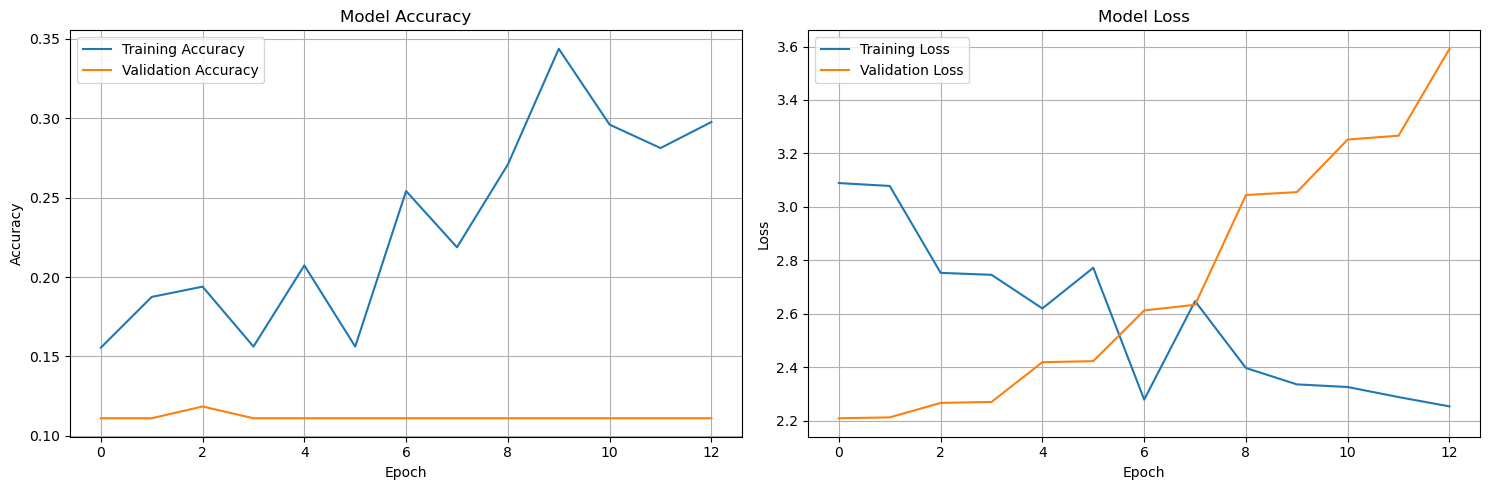


 Step 6: Advanced Signal Analysis


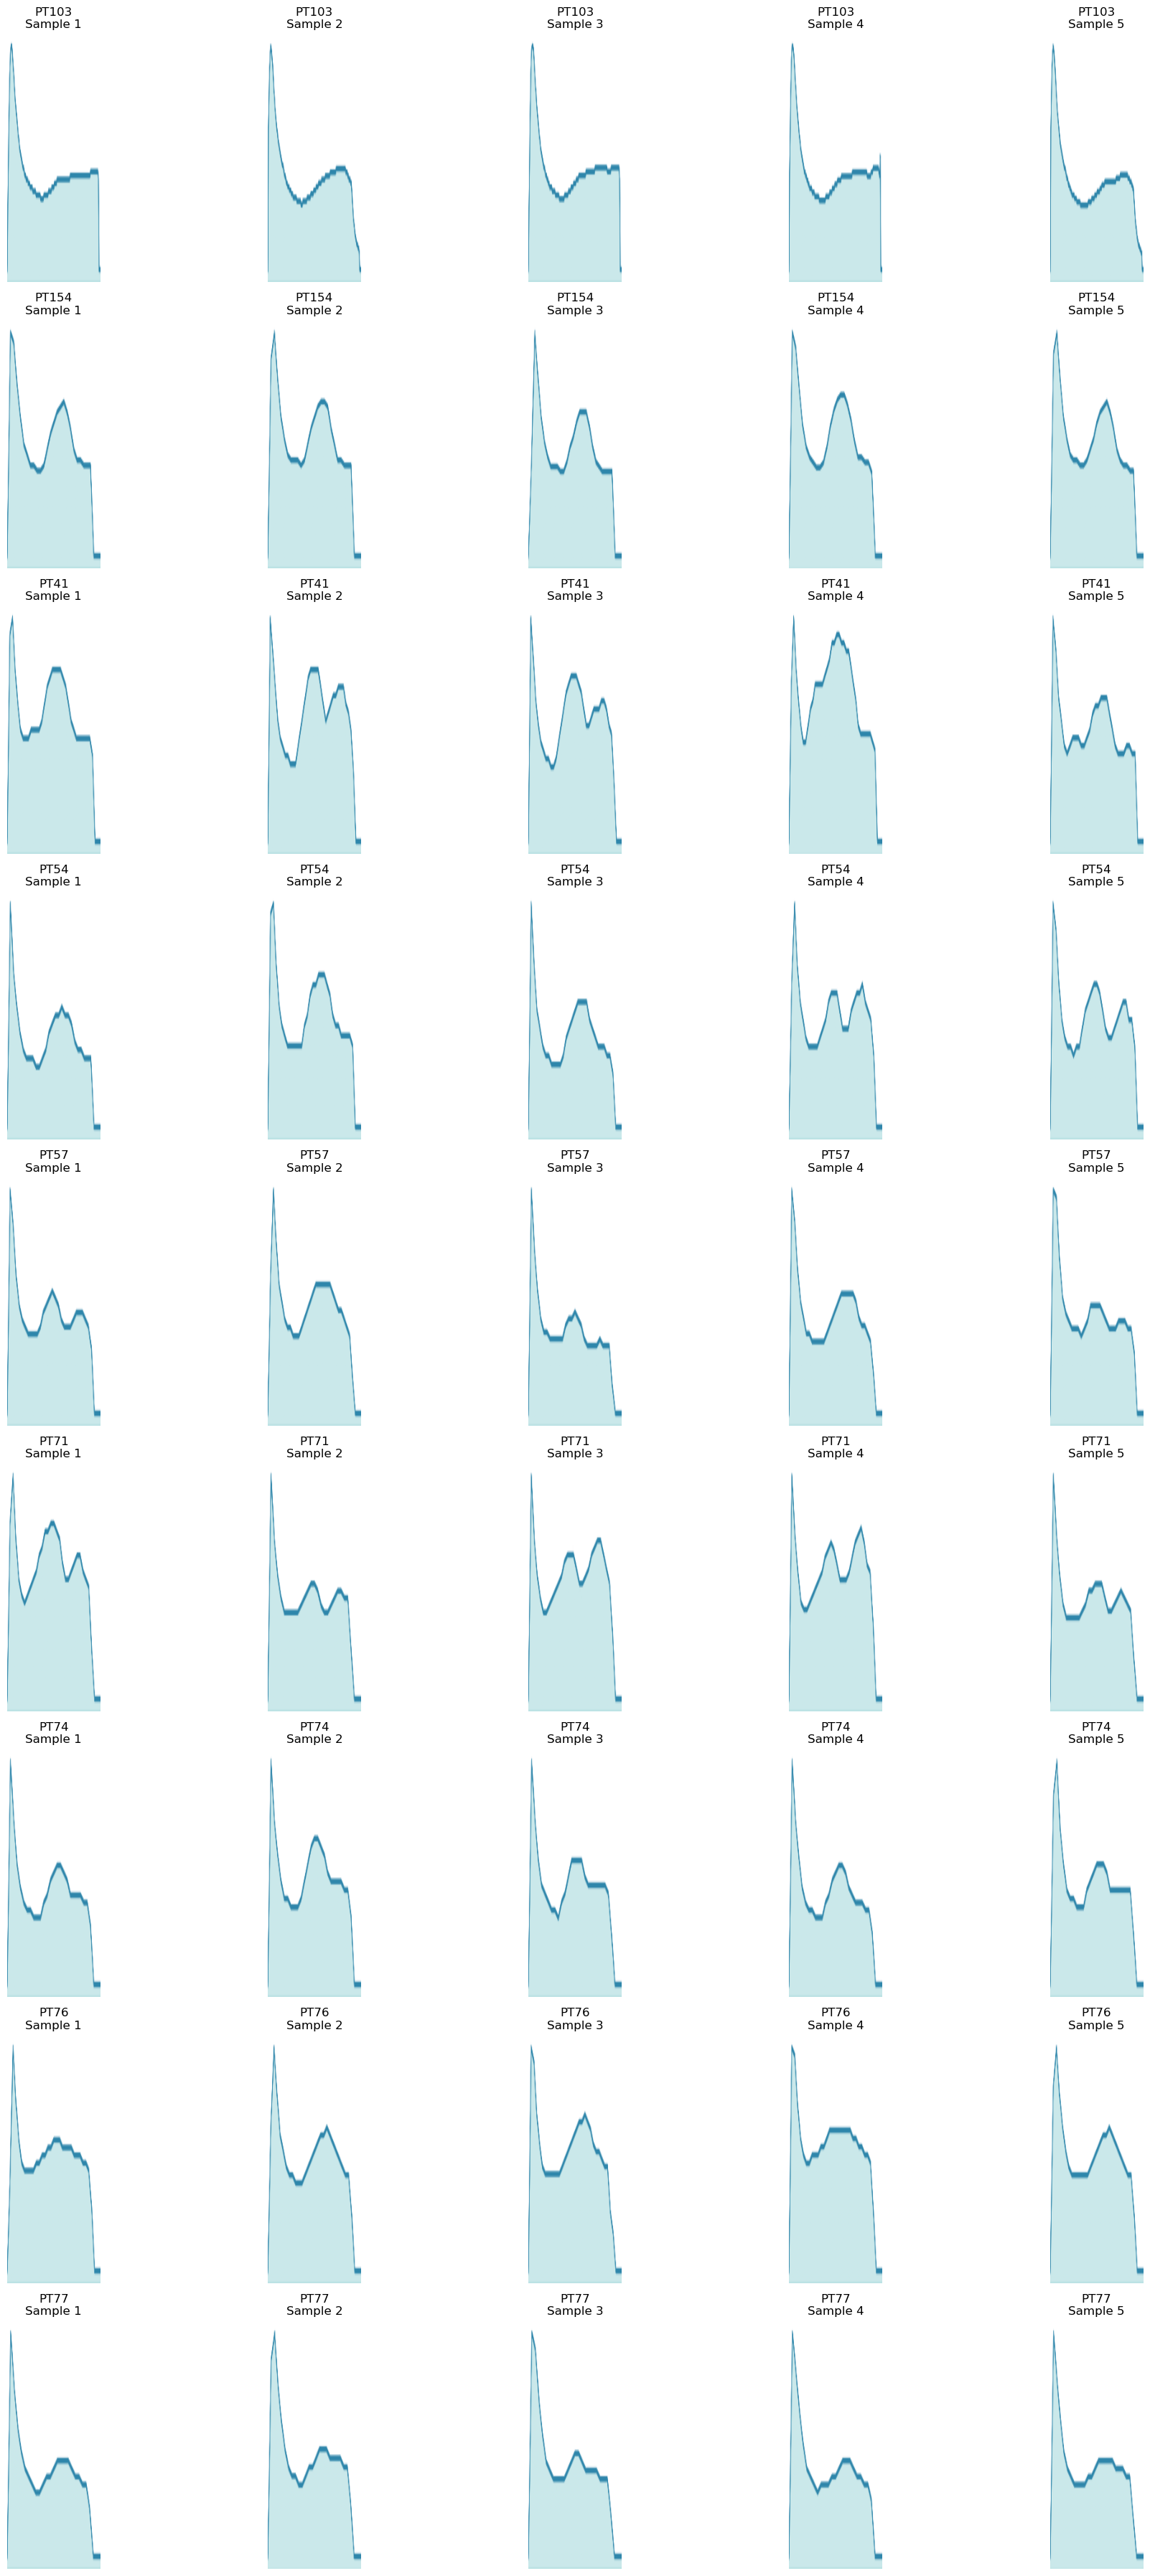

Error occurred: The layer sequential has never been called and thus has no defined input.


Traceback (most recent call last):
  File "/var/folders/6k/z_5jgpzx3gv7nz188p4vycxr0000gn/T/ipykernel_13817/1742254972.py", line 60, in main
    analyzer.visualize_feature_space(X_test, y_test)
  File "/var/folders/6k/z_5jgpzx3gv7nz188p4vycxr0000gn/T/ipykernel_13817/622192025.py", line 79, in visualize_feature_space
    features = self.extract_features(X_test)
               ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/var/folders/6k/z_5jgpzx3gv7nz188p4vycxr0000gn/T/ipykernel_13817/622192025.py", line 64, in extract_features
    inputs=self.model.input,
           ^^^^^^^^^^^^^^^^
  File "/opt/anaconda3/lib/python3.11/site-packages/keras/src/ops/operation.py", line 268, in input
    return self._get_node_attribute_at_index(0, "input_tensors", "input")
           ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/opt/anaconda3/lib/python3.11/site-packages/keras/src/ops/operation.py", line 299, in _get_node_attribute_at_index
    raise AttributeError(
AttributeError: The l

TypeError: cannot unpack non-iterable NoneType object

In [6]:
def main():
    """Main function to run the complete pipeline"""
    
    # Configuration
    DATASET_PATH = '/Users/anamikasaroha/Energy7_Week1/week_6/signal_dataset_images_v2'  
    MODEL_SAVE_PATH = 'signal_classifier_model.h5'
    LABEL_ENCODER_PATH = 'label_encoder.pkl'
    TARGET_SIZE = (150, 400)  # height, width
    
    print("Starting Signal Computer Vision Classification Pipeline")
    print("=" * 60)
    
    try:
        # Step 1: Load Dataset
        print("\n Step 1: Loading Dataset")
        dataset = SignalImageDataset(DATASET_PATH)
        
        # Step 2: Prepare Data
        print("\n Step 2: Preparing Data Arrays")
        X, y = dataset.get_data_arrays(target_size=TARGET_SIZE)
        
        print(f"Dataset shape: X={X.shape}, y={y.shape}")
        
        # Step 3: Split Data
        print("\n Step 3: Splitting Data")
        X_train, X_temp, y_train, y_temp = train_test_split(
            X, y, test_size=0.3, random_state=42, stratify=y
        )
        X_val, X_test, y_val, y_test = train_test_split(
            X_temp, y_temp, test_size=0.5, random_state=42, stratify=y_temp
        )
        
        print(f"Train: {X_train.shape[0]} samples")
        print(f"Validation: {X_val.shape[0]} samples") 
        print(f"Test: {X_test.shape[0]} samples")
        
        # Step 4: Build and Train Model
        print("\n Step 4: Building and Training CNN Model")
        num_classes = len(dataset.label_encoder.classes_)
        classifier = SignalCNNClassifier(num_classes, input_shape=TARGET_SIZE + (3,))
        
        # Train model
        history = classifier.train(X_train, y_train, X_val, y_val, epochs=30)
        
        # Step 5: Evaluate Model
        print("\n Step 5: Evaluating Model")
        accuracy, y_pred, y_pred_proba = classifier.evaluate(X_test, y_test, dataset.label_encoder)
        
        # Plot training history
        classifier.plot_training_history()
        
        # Step 6: Advanced Analysis
        print("\n Step 6: Advanced Signal Analysis")
        analyzer = SignalAnalyzer(classifier.model, dataset.label_encoder, dataset)
        
        # Analyze signal patterns
        analyzer.analyze_signal_patterns(X_test, y_test)
        
        # Visualize feature space
        analyzer.visualize_feature_space(X_test, y_test)
        
        # Step 7: Save Model and Components
        print("\n Step 7: Saving Model and Components")
        classifier.save_model(MODEL_SAVE_PATH)
        
        # Save label encoder
        with open(LABEL_ENCODER_PATH, 'wb') as f:
            pickle.dump(dataset.label_encoder, f)
        
        print(f"Label encoder saved to {LABEL_ENCODER_PATH}")
        
        # Step 8: Demo - Predict New Images
        print("\n Step 8: Demo - Testing Prediction on Sample Images")
        
        # Test on a few random images from test set
        sample_indices = np.random.choice(len(X_test), 3, replace=False)
        
        for i, idx in enumerate(sample_indices):
            # Save test image temporarily
            temp_image_path = f'temp_test_image_{i}.png'
            plt.imsave(temp_image_path, X_test[idx])
            
            # Predict
            predicted_class, confidence, class_probabilities = analyzer.predict_single_image(temp_image_path)
            actual_class = dataset.label_encoder.inverse_transform([y_test[idx]])[0]
            
            print(f"\nSample {i+1}:")
            print(f"  Actual: {actual_class}")
            print(f"  Predicted: {predicted_class}")
            print(f"  Confidence: {confidence:.4f}")
            print(f"  All probabilities: {dict(sorted(class_probabilities.items(), key=lambda x: x[1], reverse=True))}")
            
            # Clean up temp file
            os.remove(temp_image_path)
        
        # Final Summary
        print("\n" + "=" * 60)
        print("PIPELINE COMPLETED SUCCESSFULLY!")
        print("=" * 60)
        print(f"Final Test Accuracy: {accuracy:.4f}")
        print(f"Number of Classes: {num_classes}")
        print(f"Model saved as: {MODEL_SAVE_PATH}")
        print(f"Label encoder saved as: {LABEL_ENCODER_PATH}")
        print("\nGenerated Files:")
        print("  - confusion_matrix.png")
        print("  - training_history.png") 
        print("  - signal_patterns_analysis.png")
        print("  - feature_space_visualization.png")
        
        return classifier, analyzer, dataset
        
    except Exception as e:
        print(f"Error occurred: {str(e)}")
        import traceback
        traceback.print_exc()

if __name__ == "__main__":
    classifier, analyzer, dataset = main()